# UT11 - Redes Neuronales Profundas con Keras

- **Alumno:** Borja Ramos Oliva  
- **Asignatura:** Sistemas Aprendizaje Automático
- **Entrega:** Aplicación de redes neuronales densas con Keras a problemas de regresión y clasificación.
- **Enlace a video:** [Aquí](https://youtu.be/wZc7Ul3dtJo)
- **Enlace a repo de Github:** [Aquí](https://github.com/borja-ro/SAPAU)
- **Enlace al notebook en colab:** [Aquí]

En este notebook se aplican redes neuronales profundas con Keras a dos problemas ya trabajados en unidades anteriores:

1. **Regresión:** predicción del precio de la vivienda a partir de variables económicas, demográficas y territoriales.
2. **Clasificación:** clasificación binaria del dataset Breast Cancer de `sklearn`, para distinguir tumores benignos y malignos.

El objetivo no es solamente entrenar modelos, sino seguir un flujo completo de trabajo: definición del problema, preprocesado, construcción de la red, entrenamiento con validación, análisis de pérdidas, predicciones, comparación con modelos clásicos y conclusiones.

## Índice

1. [Configuración inicial](#configuracion-inicial)
2. [Regresión con Keras](#regresion-con-keras)
   - 2.1 Importación y preprocesado del dataset
   - 2.2 Construcción de la red neuronal
   - 2.3 Entrenamiento del modelo
   - 2.4 Visualización de la función de pérdidas
   - 2.5 Predicción de nuevos valores
   - 2.6 Comparación con modelos clásicos
   - 2.7 Conclusiones de regresión
3. [Clasificación con Keras](#clasificacion-con-keras)
   - 3.1 Importación y preprocesado del dataset
   - 3.2 Construcción de la red neuronal
   - 3.3 Entrenamiento del modelo
   - 3.4 Evaluación del modelo
   - 3.5 Visualización de pérdidas y métricas
   - 3.6 Guardado y carga del modelo
   - 3.7 Predicciones con el modelo cargado
   - 3.8 Comparación con modelos clásicos
   - 3.9 Conclusiones de clasificación
4. [Conclusiones finales](#conclusiones-finales)

<a id="configuracion-inicial"></a>
## 1. Configuración inicial

Se importan las librerías principales para el tratamiento de datos, visualización, preprocesado, evaluación y construcción de modelos con Keras.

También se fija una semilla para mejorar la reproducibilidad de los resultados.

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.datasets import load_breast_cancer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


<a id="regresion-con-keras"></a>
# 2. Regresión con Keras

En este apartado se aplica una red neuronal densa a un problema de **regresión**, donde el objetivo es predecir el **precio** , que es variable numérica continua

Según vemos en el flujo de trabajo, en una tarea de regresión la capa final debe tener una única neurona y normalmente no se utiliza función de activación en la salida, ya que pretendemos obtener un valor real continuo.

## 2.1 Importación y preprocesado del dataset

Hemos utilizado el dataset trabajado en la UT5 de regresión. [Se puede encontrar aquí](https://github.com/borja-ro/SAPAU/blob/main/UT5%20Regresion/data2/datos_unidos_meses.csv). El target es la columna `precio`

En el preprocesado hacemos:

- carga del dataset,
- comprobación de valores missing,
- separación entre variables predictoras y variable objetivo,
- codificación onehot para variables categóricas,
- imputación de posibles valores nulos,
- escalado de variables numéricas.

El escalado es especialmente importante en redes neuronales, porque ayuda a que el proceso de optimización sea más estable.

In [ ]:
# Ruta flexible para que funcione tanto en local como en Colab.
# En Colab, sube el archivo datos_unidos_meses.csv al entorno o colócalo en la carpeta adecuada.
posibles_rutas = [
    "datos_unidos_meses.csv",
    "data/datos_unidos_meses.csv",
    "data2/datos_unidos_meses.csv",
    "/mnt/data/datos_unidos_meses.csv"
]
# Para Google Colab, leer directamente desde github según he comentado antes al principio del apartado 2.1 , y descomentar:
# df_reg = pd.read_csv("https://raw.githubusercontent.com/borja-ro/SAPAU/main/UT5%20Regresion/data2/datos_unidos_meses.csv")

ruta_dataset = None
for ruta in posibles_rutas:
    if os.path.exists(ruta):
        ruta_dataset = ruta
        break

if ruta_dataset is None:
    raise FileNotFoundError("No se ha encontrado datos_unidos_meses.csv. Sube el archivo al entorno de ejecución.")

df_reg = pd.read_csv(ruta_dataset)

print(f"Dataset cargado desde: {ruta_dataset}")
print(f"Dimensiones: {df_reg.shape}")
df_reg.head()

Dataset cargado desde: datos_unidos_meses.csv
Dimensiones: (1386, 18)


,codigo_comunidad,comunidad,name,year,precio,IPC,edad_media,mano_obra,precio_Acero,precio_Aluminio,precio_Cemento,precio_Ceramica,precio_Cobre,precio_Energía,precio_Ligantes,precio_Madera,num_hipotecas,num_inmigracion
0,1,andalucia,Andalucía,2003-01-01,995.0,72.838,37.951542,313.00,719.9,725.8,1349.9,1227.4,558.2,2017.0,1453.9,1507.4,69821,205704
1,1,andalucia,Andalucía,2003-04-01,1033.0,74.225,37.951542,317.54,730.7,728.3,1343.7,1227.2,527.6,1940.9,1525.7,1507.2,57326,213822
2,1,andalucia,Andalucía,2003-07-01,1094.0,73.579,38.049990,315.92,724.4,704.8,1324.6,1226.0,541.2,1865.3,1517.8,1512.6,52571,221941
3,1,andalucia,Andalucía,2003-10-01,1133.0,74.736,38.049990,319.96,717.4,705.4,1331.2,1224.4,590.5,1817.3,1445.2,1512.9,63411,230060
4,1,andalucia,Andalucía,2004-01-01,1186.0,74.391,38.146028,319.41,735.7,711.7,1342.7,1226.0,689.3,1773.3,1262.8,1517.9,79923,238178


In [3]:
print("Información general del dataset:")
df_reg.info()

print("\nValores nulos por columna:")
nulos = df_reg.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos.")

print(f"\nFilas duplicadas: {df_reg.duplicated().sum()}")

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   codigo_comunidad  1386 non-null   int64  
 1   comunidad         1386 non-null   object 
 2   name              1386 non-null   object 
 3   year              1386 non-null   object 
 4   precio            1386 non-null   float64
 5   IPC               1386 non-null   float64
 6   edad_media        1386 non-null   float64
 7   mano_obra         1386 non-null   float64
 8   precio_Acero      1386 non-null   float64
 9   precio_Aluminio   1386 non-null   float64
 10  precio_Cemento    1386 non-null   float64
 11  precio_Ceramica   1386 non-null   float64
 12  precio_Cobre      1386 non-null   float64
 13  precio_Energía    1386 non-null   float64
 14  precio_Ligantes   1386 non-null   float64
 15  precio_Madera     1386 non-null   float64
 16  num_hipot

In [ ]:
# Eliminamos duplicados si hay
df_reg = df_reg.drop_duplicates().copy()

TARGET_REG = "precio"

X_reg = df_reg.drop(columns=[TARGET_REG])
y_reg = df_reg[TARGET_REG]

cat_cols_reg = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=["number"]).columns.tolist()

print("Variables categóricas:", cat_cols_reg)
print("Variables numéricas:", num_cols_reg)
print("Target:", TARGET_REG)

Variables categóricas: ['comunidad', 'name', 'year']
Variables numéricas: ['codigo_comunidad', 'IPC', 'edad_media', 'mano_obra', 'precio_Acero', 'precio_Aluminio', 'precio_Cemento', 'precio_Ceramica', 'precio_Cobre', 'precio_Energía', 'precio_Ligantes', 'precio_Madera', 'num_hipotecas', 'num_inmigracion']
Target: precio


In [ ]:
# División train/test.
# Usamos test solo al final para evaluar el rendimiento real del modelo.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=SEED
)

print("Tamaño entrenamiento:", X_train_reg.shape)
print("Tamaño test:", X_test_reg.shape)

Tamaño entrenamiento: (1108, 17)
Tamaño test: (278, 17)


In [6]:
# Preprocesado:
# - numéricas: imputación con mediana + StandardScaler
# - categóricas: imputación con moda + OneHotEncoder

numeric_transformer_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_reg, num_cols_reg),
        ("cat", categorical_transformer_reg, cat_cols_reg)
    ]
)

X_train_reg_prep = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_prep = preprocessor_reg.transform(X_test_reg)

# Escalamos también el target para facilitar el entrenamiento de la red.
y_scaler_reg = StandardScaler()
y_train_reg_scaled = y_scaler_reg.fit_transform(y_train_reg.values.reshape(-1, 1)).ravel()
y_test_reg_scaled = y_scaler_reg.transform(y_test_reg.values.reshape(-1, 1)).ravel()

print("Shape tras preprocesado - train:", X_train_reg_prep.shape)
print("Shape tras preprocesado - test:", X_test_reg_prep.shape)

Shape tras preprocesado - train: (1108, 127)
Shape tras preprocesado - test: (278, 127)


## 2.2 Construcción de la red neuronal

Se construye un modelo secuencial con capas densas (`Dense`).

Arquitectura aplicada:

- capa de entrada adaptada al número de variables tras el preprocesado,
- capas ocultas con activación `relu`, adecuada para aprender relaciones no lineales,
- capa final `Dense(1)` sin activación, porque el problema es de regresión.

Como función de pérdida se utiliza `mse` porque penaliza los errores grandes, y como métrica adicional se usa `mae`, más interpretable en términos de error medio absoluto.

In [7]:
def crear_modelo_regresion(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )
    return model

modelo_reg = crear_modelo_regresion(X_train_reg_prep.shape[1])
modelo_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,817 (42.25 KB)

 Trainable params: 10,817 (42.25 KB)

 Non-trainable params: 0 (0.00 B)

## 2.3 Entrenamiento del modelo

El modelo se entrena usando un conjunto de validación extraído del conjunto de entrenamiento.

Se utiliza `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar. Esto ayuda a evitar el sobreajuste y permite recuperar automáticamente los mejores pesos encontrados durante el entrenamiento.

In [8]:
early_stop_reg = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_reg = modelo_reg.fit(
    X_train_reg_prep,
    y_train_reg_scaled,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_reg],
    verbose=1
)

Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8711 - mae: 0.7398 - val_loss: 0.7315 - val_mae: 0.6254
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4846 - mae: 0.5247 - val_loss: 0.3202 - val_mae: 0.4135
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1890 - mae: 0.3075 - val_loss: 0.0987 - val_mae: 0.2212
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0613 - mae: 0.1785 - val_loss: 0.0517 - val_mae: 0.1613
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0329 - mae: 0.1347 - val_loss: 0.0373 - val_mae: 0.1352
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0217 - mae: 0.1093 - val_loss: 0.0299 - val_mae: 0.1197
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0156 - mae: 0.0924 - val_loss: 0.0256 - val_mae: 0.1112
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0117 - mae: 0.0803 - val_loss: 0.0225 - val_mae: 0.1051
Epoch 9/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.009

## 2.4 Visualización de la función de pérdidas

Se representan las curvas de pérdida del entrenamiento y la validación.

La aparición de **overfitting** se detecta cuando la pérdida de entrenamiento sigue bajando pero la pérdida de validación se estabiliza o comienza a subir.

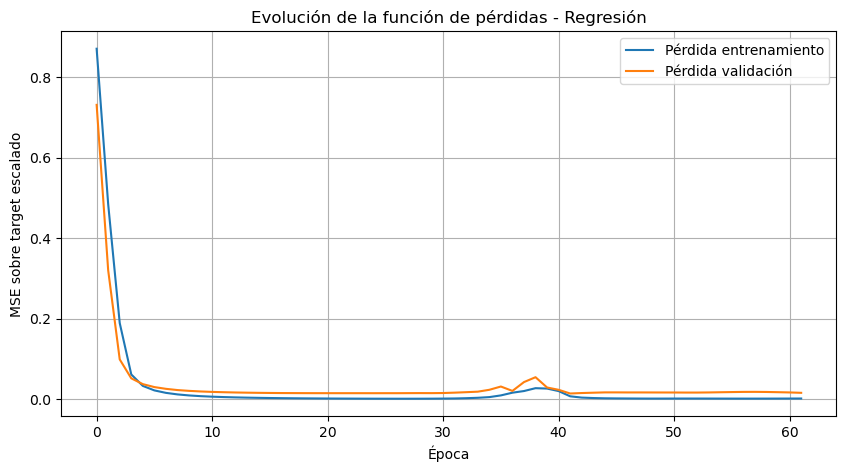

Mejor época según val_loss: 42
A partir de ese punto, si la pérdida de validación deja de mejorar mientras la de entrenamiento baja, puede aparecer overfitting.


In [9]:
def plot_history_regresion(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Pérdida entrenamiento")
    plt.plot(history.history["val_loss"], label="Pérdida validación")
    plt.xlabel("Época")
    plt.ylabel("MSE sobre target escalado")
    plt.title("Evolución de la función de pérdidas - Regresión")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history_regresion(history_reg)

best_epoch_reg = int(np.argmin(history_reg.history["val_loss"]) + 1)
print(f"Mejor época según val_loss: {best_epoch_reg}")
print("A partir de ese punto, si la pérdida de validación deja de mejorar mientras la de entrenamiento baja, puede aparecer overfitting.")

## 2.5 Utilizar el modelo para predecir nuevos valores

Se realizan predicciones sobre el conjunto de test. Como el target fue escalado para entrenar la red, las predicciones se transforman de nuevo a la escala original del precio.

In [10]:
y_pred_reg_scaled = modelo_reg.predict(X_test_reg_prep).ravel()
y_pred_reg = y_scaler_reg.inverse_transform(y_pred_reg_scaled.reshape(-1, 1)).ravel()

resultados_reg = pd.DataFrame({
    "precio_real": y_test_reg.values,
    "precio_predicho": y_pred_reg,
    "error": y_test_reg.values - y_pred_reg
})

resultados_reg.head(10)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,precio_real,precio_predicho,error
0,2684.0,2734.499756,-50.499756
1,1287.0,1296.064575,-9.064575
2,2729.0,2722.063721,6.936279
3,2283.0,2298.337646,-15.337646
4,1001.0,950.227417,50.772583
5,1197.0,1194.380005,2.619995
6,823.0,825.445984,-2.445984
7,1763.0,1798.985352,-35.985352
8,1612.0,1632.055542,-20.055542
9,2923.0,2832.881836,90.118164


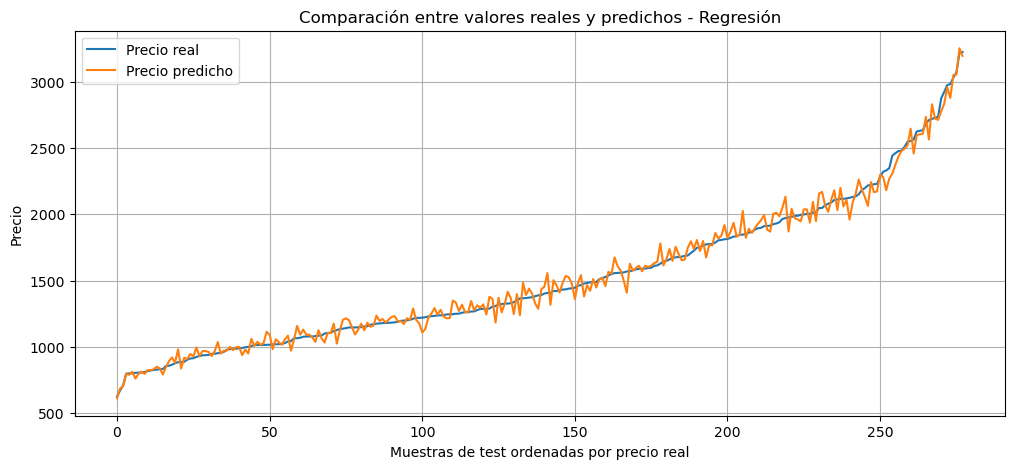

In [11]:
# Gráfico de líneas: valores reales vs valores predichos.
# Se ordenan por valor real para facilitar la lectura visual.
resultados_plot_reg = resultados_reg.sort_values("precio_real").reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(resultados_plot_reg["precio_real"].values, label="Precio real")
plt.plot(resultados_plot_reg["precio_predicho"].values, label="Precio predicho")
plt.xlabel("Muestras de test ordenadas por precio real")
plt.ylabel("Precio")
plt.title("Comparación entre valores reales y predichos - Regresión")
plt.legend()
plt.grid(True)
plt.show()

## 2.6 Comparación de métricas con modelos clásicos

Se calculan las principales métricas de regresión:

- **MSE:** error cuadrático medio.
- **RMSE:** raíz del error cuadrático medio, en la misma escala que el target.
- **MAE:** error absoluto medio.
- **R²:** proporción de varianza explicada por el modelo.

Después se comparan con los modelos de Machine Learning utilizados en la unidad anterior.

In [12]:
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

metricas_keras_reg = pd.DataFrame({
    "Modelo": ["Red neuronal Keras"],
    "MSE": [mse_reg],
    "RMSE": [rmse_reg],
    "MAE": [mae_reg],
    "R2": [r2_reg]
})

metricas_keras_reg

,Modelo,MSE,RMSE,MAE,R2
0,Red neuronal Keras,3487.526262,59.055281,44.873993,0.988377


In [13]:
# Métricas obtenidas en el trabajo anterior de regresión.
# Se incluyen para poder comparar la red neuronal con algoritmos clásicos.
comparacion_reg = pd.DataFrame({
    "Modelo": [
        "Regresión lineal múltiple",
        "Regresión polinomial grado 2",
        "SVR",
        "Árbol de decisión",
        "Random Forest",
        "Red neuronal Keras"
    ],
    "RMSE": [143.94, 33.12, 137.65, 151.98, 68.12, rmse_reg],
    "R2": [0.9310, 0.9963, 0.9369, 0.9230, 0.9845, r2_reg]
})

comparacion_reg.sort_values("RMSE")

,Modelo,RMSE,R2
1,Regresión polinomial grado 2,33.120000,0.996300
5,Red neuronal Keras,59.055281,0.988377
4,Random Forest,68.120000,0.984500
2,SVR,137.650000,0.936900
0,Regresión lineal múltiple,143.940000,0.931000
3,Árbol de decisión,151.980000,0.923000


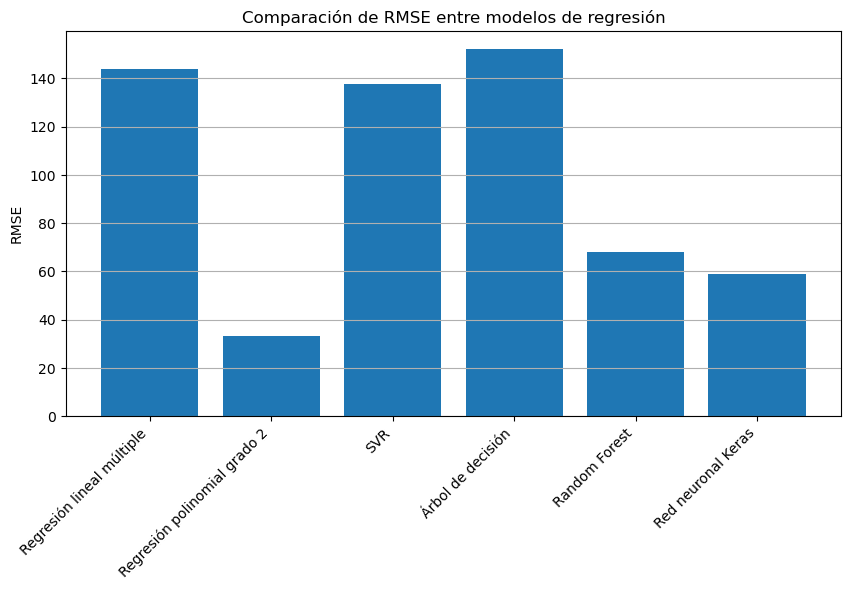

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(comparacion_reg["Modelo"], comparacion_reg["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Comparación de RMSE entre modelos de regresión")
plt.grid(axis="y")
plt.show()

## 2.7 Conclusiones de regresión

La red neuronal permite abordar el problema de predicción de precios como una tarea de regresión no lineal. El uso de capas densas con activación `relu` permite capturar relaciones complejas entre las variables de entrada.

En este caso se ha aplicado un preprocesado completo: imputación, codificación de variables categóricas, escalado de variables numéricas y escalado del target. El escalado del target mejora la estabilidad del entrenamiento, ya que la red trabaja con valores centrados y normalizados.

La curva de pérdidas permite analizar si el modelo aprende correctamente y si aparece sobreajuste. El uso de validación y `EarlyStopping` evita entrenar más épocas de las necesarias.

La comparación con modelos clásicos permite valorar si la red neuronal mejora o no los resultados anteriores. En datasets tabulares de tamaño moderado, modelos como Random Forest o regresión polinomial pueden ser muy competitivos, por lo que una red neuronal no siempre garantiza mejores resultados automáticamente. Su rendimiento depende de la arquitectura, el preprocesado y la cantidad/calidad de datos disponibles.

<a id="clasificacion-con-keras"></a>
# 3. Clasificación con Keras

En este apartado se aplica una red neuronal densa a un problema de **clasificación binaria** usando el dataset Breast Cancer de `sklearn`.

El objetivo es predecir si una muestra corresponde a un tumor maligno o benigno a partir de 30 variables numéricas obtenidas de imágenes digitalizadas de biopsias.

En clasificación binaria se utiliza una única neurona de salida con activación `sigmoid`, que devuelve una probabilidad entre 0 y 1.

## 3.1 Importación y preprocesado del dataset

El dataset Breast Cancer viene incluido en `sklearn`, por lo que no es necesario cargar un archivo externo.

El preprocesado incluye:

- carga del dataset,
- comprobación de missing,
- revisión de variables categóricas,
- separación entre matriz de características y target,
- división en entrenamiento y test con estratificación,
- estandarización de variables.

In [15]:
data = load_breast_cancer()

X_clf = pd.DataFrame(data.data, columns=data.feature_names)
y_clf = pd.Series(data.target, name="target")  # 0 = maligno, 1 = benigno

df_clf = pd.concat([X_clf, y_clf], axis=1)

print(f"Dimensiones: {df_clf.shape}")
print("Clases:", data.target_names)
print("Distribución del target:")
print(y_clf.value_counts())

df_clf.head()

Dimensiones: (569, 31)
Clases: ['malignant' 'benign']
Distribución del target:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [16]:
print("Valores missing:")
missing_clf = df_clf.isnull().sum()
print(missing_clf[missing_clf > 0] if missing_clf.sum() > 0 else "No hay valores missing.")

cat_cols_clf = X_clf.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_clf = X_clf.select_dtypes(include=["number"]).columns.tolist()

print("\nVariables categóricas:", cat_cols_clf)
print("Variables numéricas:", len(num_cols_clf))

Valores missing:
No hay valores missing.

Variables categóricas: []
Variables numéricas: 30


In [17]:
# Aunque este dataset no tiene variables categóricas, se muestra un ejemplo mínimo de codificación
# para justificar el apartado solicitado en el enunciado.
ejemplo_cat = pd.DataFrame({
    "diagnostico_texto": ["benigno", "maligno", "benigno", "maligno"]
})

ejemplo_dummies = pd.get_dummies(ejemplo_cat, drop_first=True)
print("Ejemplo de variable categórica codificada con dummies:")
display(ejemplo_dummies)

Ejemplo de variable categórica codificada con dummies:


,diagnostico_texto_maligno
0,False
1,True
2,False
3,True


In [18]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=SEED,
    stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Tamaño entrenamiento:", X_train_clf_scaled.shape)
print("Tamaño test:", X_test_clf_scaled.shape)
print("Proporción clase 1 en train:", y_train_clf.mean())
print("Proporción clase 1 en test:", y_test_clf.mean())

Tamaño entrenamiento: (455, 30)
Tamaño test: (114, 30)
Proporción clase 1 en train: 0.6263736263736264
Proporción clase 1 en test: 0.631578947368421


## 3.2 Construcción de la red neuronal

Se construye una red neuronal densa para clasificación binaria.

La arquitectura elegida es:

- capa de entrada con 30 variables,
- dos capas ocultas con activación `relu`,
- capa final con una neurona y activación `sigmoid`.

La función de pérdida seleccionada es `binary_crossentropy`, adecuada cuando el target tiene dos clases. La métrica principal es `accuracy`, aunque también se analizarán precision, recall y F1-score.

In [19]:
def crear_modelo_clasificacion(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

modelo_clf = crear_modelo_clasificacion(X_train_clf_scaled.shape[1])
modelo_clf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3.3 Entrenamiento del modelo

El modelo se entrena usando datos de validación. De nuevo se utiliza `EarlyStopping` para conservar los mejores pesos y evitar entrenamientos innecesariamente largos.

In [20]:
early_stop_clf = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_clf = modelo_clf.fit(
    X_train_clf_scaled,
    y_train_clf,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop_clf],
    verbose=1
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4835 - loss: 0.8696 - val_accuracy: 0.6813 - val_loss: 0.5569
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8434 - loss: 0.4261 - val_accuracy: 0.9341 - val_loss: 0.3205
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9341 - loss: 0.2643 - val_accuracy: 0.9560 - val_loss: 0.2255
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9533 - loss: 0.1903 - val_accuracy: 0.9670 - val_loss: 0.1709
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9588 - loss: 0.1485 - val_accuracy: 0.9670 - val_loss: 0.1375
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9643 - loss: 0.1228 - val_accuracy: 0.9670 - val_loss: 0.1173
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9725 - loss: 0.1056 - val_accuracy: 0.9670 - val_loss: 0.1024
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9780 - loss: 0.0933 - val_accuracy: 0.9670 - v

## 3.4 Evaluación del modelo

Se evalúa el modelo sobre el conjunto de test, que no ha sido utilizado durante el entrenamiento ni para ajustar hiperparámetros.

In [21]:
test_loss_clf, test_acc_clf = modelo_clf.evaluate(X_test_clf_scaled, y_test_clf, verbose=0)

print(f"Loss en test: {test_loss_clf:.4f}")
print(f"Accuracy en test: {test_acc_clf:.4f}")

Loss en test: 0.1436
Accuracy en test: 0.9561


## 3.5 Visualización de pérdidas y métricas

Se visualizan tanto la pérdida como la exactitud (`accuracy`) en entrenamiento y validación.

El overfitting aparecería si la pérdida de entrenamiento siguiera disminuyendo mientras la pérdida de validación aumentara de forma sostenida.

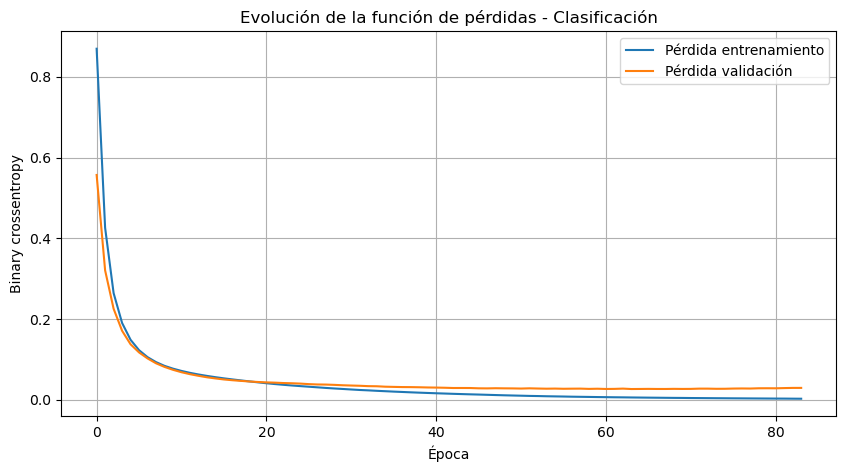

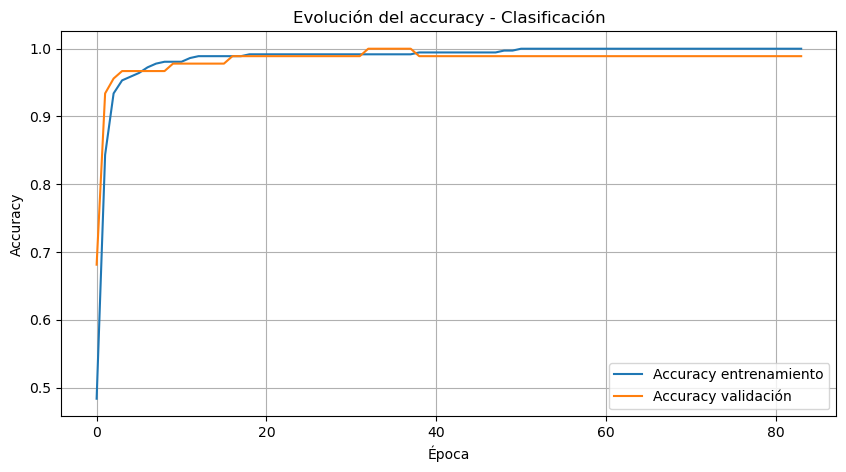

Mejor época según val_loss: 64


In [22]:
def plot_history_clasificacion(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history["loss"], label="Pérdida entrenamiento")
    plt.plot(history.history["val_loss"], label="Pérdida validación")
    plt.xlabel("Época")
    plt.ylabel("Binary crossentropy")
    plt.title("Evolución de la función de pérdidas - Clasificación")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(history.history["accuracy"], label="Accuracy entrenamiento")
    plt.plot(history.history["val_accuracy"], label="Accuracy validación")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title("Evolución del accuracy - Clasificación")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history_clasificacion(history_clf)

best_epoch_clf = int(np.argmin(history_clf.history["val_loss"]) + 1)
print(f"Mejor época según val_loss: {best_epoch_clf}")

In [23]:
# Predicciones en probabilidad y conversión a clase.
y_prob_clf = modelo_clf.predict(X_test_clf_scaled).ravel()
y_pred_clf = (y_prob_clf >= 0.5).astype(int)

acc_clf = accuracy_score(y_test_clf, y_pred_clf)
precision_clf = precision_score(y_test_clf, y_pred_clf)
recall_clf = recall_score(y_test_clf, y_pred_clf)
f1_clf = f1_score(y_test_clf, y_pred_clf)

metricas_keras_clf = pd.DataFrame({
    "Modelo": ["Red neuronal Keras"],
    "Accuracy": [acc_clf],
    "Precision": [precision_clf],
    "Recall": [recall_clf],
    "F1-score": [f1_clf]
})

metricas_keras_clf

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,Modelo,Accuracy,Precision,Recall,F1-score
0,Red neuronal Keras,0.95614,0.985507,0.944444,0.964539


Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



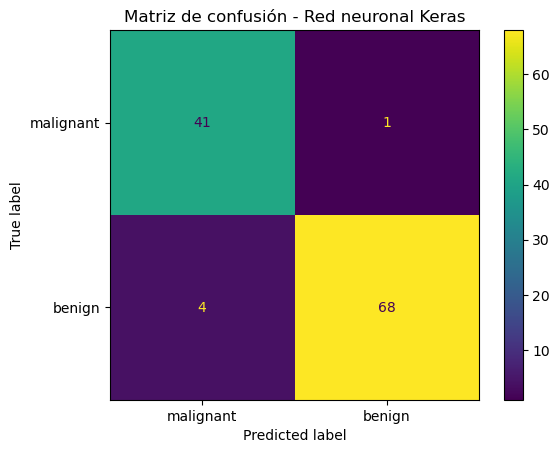

In [24]:
print("Classification report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=data.target_names))

cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(values_format="d")
plt.title("Matriz de confusión - Red neuronal Keras")
plt.show()

## 3.6 Guardar el modelo

El enunciado solicita guardar el modelo. Se guarda en formato `.keras`, que es el formato nativo recomendado actualmente por Keras.

In [25]:
ruta_modelo_clf = "modelo_breast_cancer_keras.keras"
modelo_clf.save(ruta_modelo_clf)

print(f"Modelo guardado en: {ruta_modelo_clf}")

Modelo guardado en: modelo_breast_cancer_keras.keras


## 3.7 Cargar el modelo y efectuar predicciones

Se carga el modelo guardado y se comprueba que puede volver a utilizarse para predecir nuevos datos.

In [26]:
modelo_clf_cargado = keras.models.load_model(ruta_modelo_clf)

# Predicciones con el modelo cargado.
y_prob_cargado = modelo_clf_cargado.predict(X_test_clf_scaled).ravel()
y_pred_cargado = (y_prob_cargado >= 0.5).astype(int)

print("Accuracy con el modelo cargado:", accuracy_score(y_test_clf, y_pred_cargado))

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/stepWARNING:tensorflow:6 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x17cc37a60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy con el modelo cargado: 0.956140350877193


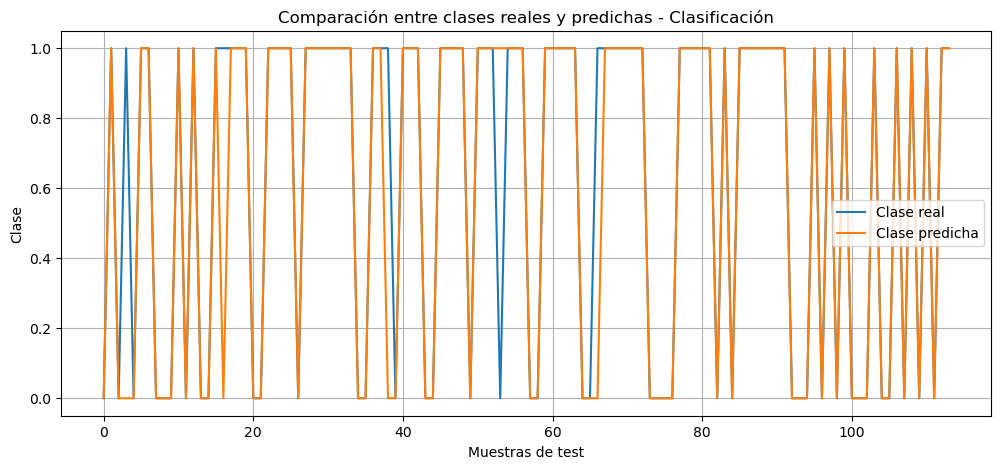

,real,predicho,probabilidad_clase_1
0,0,0,1.643980e-15
1,1,1,1.000000e+00
2,0,0,2.665354e-06
3,1,0,5.095977e-02
4,0,0,3.294593e-17
5,1,1,9.998873e-01
6,1,1,9.999999e-01
7,0,0,8.989501e-13
8,0,0,4.515654e-10
9,0,0,6.894372e-23


In [27]:
# Gráfico de líneas: valores reales vs valores predichos.
comparacion_pred_clf = pd.DataFrame({
    "real": y_test_clf.values,
    "predicho": y_pred_cargado,
    "probabilidad_clase_1": y_prob_cargado
}).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(comparacion_pred_clf["real"].values, label="Clase real")
plt.plot(comparacion_pred_clf["predicho"].values, label="Clase predicha")
plt.xlabel("Muestras de test")
plt.ylabel("Clase")
plt.title("Comparación entre clases reales y predichas - Clasificación")
plt.legend()
plt.grid(True)
plt.show()

comparacion_pred_clf.head(10)

## 3.8 Comparación de métricas con modelos clásicos

Se compara la red neuronal con los modelos clásicos utilizados en la unidad anterior de clasificación.

En este dataset, modelos como regresión logística y SVM suelen funcionar muy bien porque el dataset está bastante limpio, es numérico y tiene una separación razonablemente clara entre clases.

In [28]:
comparacion_clf = pd.DataFrame({
    "Modelo": [
        "Regresión logística",
        "SVM RBF",
        "SVM lineal",
        "Random Forest",
        "KNN",
        "Naive Bayes",
        "Árbol de decisión",
        "Red neuronal Keras"
    ],
    "Accuracy": [
        0.9825,
        0.9825,
        0.9737,
        0.9561,
        0.9561,
        0.9298,
        0.9123,
        acc_clf
    ]
})

comparacion_clf.sort_values("Accuracy", ascending=False)

,Modelo,Accuracy
0,Regresión logística,0.98250
1,SVM RBF,0.98250
2,SVM lineal,0.97370
7,Red neuronal Keras,0.95614
3,Random Forest,0.95610
4,KNN,0.95610
5,Naive Bayes,0.92980
6,Árbol de decisión,0.91230


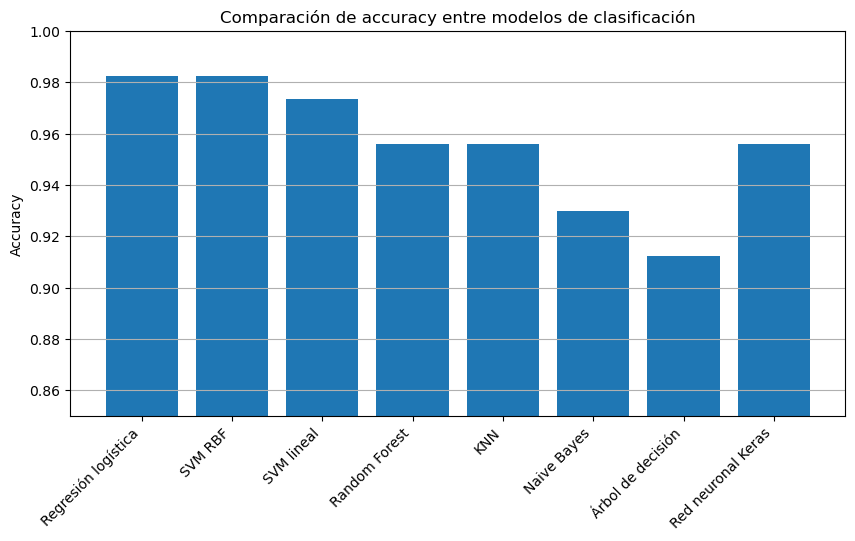

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(comparacion_clf["Modelo"], comparacion_clf["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.title("Comparación de accuracy entre modelos de clasificación")
plt.grid(axis="y")
plt.show()

## 3.9 Conclusiones de clasificación

La red neuronal se ha aplicado a un problema de clasificación binaria utilizando una arquitectura densa sencilla. La salida `sigmoid` permite interpretar la predicción como una probabilidad de pertenecer a la clase positiva.

El dataset Breast Cancer es adecuado para este tipo de práctica porque todas sus variables son numéricas y no requiere codificación categórica real. Aun así, se ha incluido una demostración de codificación para cubrir el flujo completo de preprocesado.

Las curvas de pérdida y accuracy permiten comprobar si el modelo aprende correctamente y si aparece sobreajuste. El uso de validación y `EarlyStopping` ayuda a controlar este riesgo.

La comparación con modelos clásicos muestra que, en datasets tabulares relativamente pequeños y limpios, algoritmos como regresión logística o SVM pueden igualar o superar a una red neuronal. Esto no significa que la red neuronal sea mala, sino que las redes profundas suelen destacar especialmente cuando hay muchos datos, relaciones complejas o entradas no estructuradas como imágenes, audio o texto.

<a id="conclusiones-finales"></a>
# 4. Conclusiones finales

En este trabajo se han aplicado redes neuronales profundas con Keras a dos tipos de problemas supervisados: regresión y clasificación.

En la parte de regresión, la red neuronal se ha utilizado para predecir el precio de la vivienda. Se ha comprobado la importancia del preprocesado, especialmente la codificación de variables categóricas, la estandarización de las variables numéricas y el escalado del target. La arquitectura empleada ha seguido el patrón de red densa con salida lineal para valores continuos.

En la parte de clasificación, se ha utilizado el dataset Breast Cancer. Al tratarse de un problema binario, se ha aplicado una salida con activación `sigmoid` y función de pérdida `binary_crossentropy`. Además, se ha guardado y cargado el modelo para comprobar que puede reutilizarse posteriormente.

La principal conclusión técnica es que Keras permite construir modelos de forma clara y flexible, pero el buen rendimiento no depende solamente de usar redes neuronales. También influyen el tamaño del dataset, el preprocesado, la arquitectura, la función de pérdida, la métrica elegida y el control del overfitting.

Además, la comparación con modelos clásicos es fundamental: una red neuronal no siempre supera automáticamente a algoritmos como Random Forest, SVM o regresión logística, especialmente en problemas tabulares de tamaño moderado. Por ello, el flujo correcto consiste en entrenar, validar, comparar y justificar las decisiones tomadas.